In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## **Data loading** ##

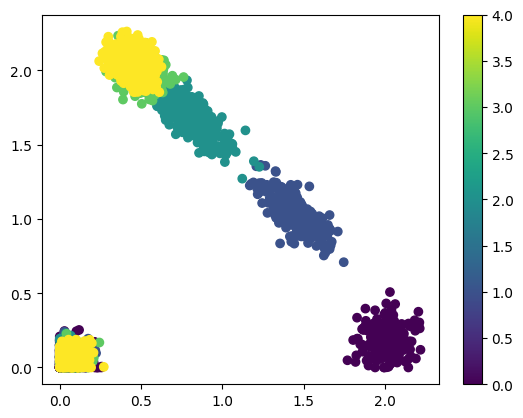

In [2]:
data_name = 'simulation'
nu = 0.1
delta = 2
legend_loc = 'upper right'

# data_name = 'mouse'
# nu = 2
# delta = 15

# data_name = 'Dygen'
# nu = 0.1
# delta = 1.7
# legend_loc = 'upper left'

data = pd.read_csv('data/simulation_gene_data.csv')
# data = pd.read_csv('data/Weinreb_alltime.csv')
# data = pd.read_csv('data/dygen.csv')

t = np.array(data)[:,0]
X = np.array(data)[:,1:]
X1 = X[:,0]
X2 = X[:,1]
plt.scatter(X1,X2,c=t)
plt.colorbar()

## **Branching plot** ##

In [3]:
from utils import SDE, plot_branching_phase_portrait, plot_branching_phase_portrait2
Xs = [] 
max_sample_time = int(np.max(data['samples']))
for k in range(max_sample_time + 1): 
    Xs.append(np.array(data[data['samples'] == k])[:, 1:]) 

model = torch.load(f'{data_name}_{delta}_{nu}.pth', weights_only=False, map_location=torch.device('cpu'))
model.eval()
simulator = SDE(model, nu, mode = 3, positive=False) 
        
# Simulation use X0[170,399]
# Dygen use X0[12,133,12,14,148,100,10,2,127]
# x_source = torch.tensor(Xs[0][np.array([0,1,2,3,4,5,6,7,8,9,10]),:], dtype=torch.float32, device = 'cpu') 

split_x1 = []
split_x2 = []

for i in range(20):
    print(i,len(split_x1))
    x_source = torch.tensor(Xs[0][i*10:(i+1)*10], dtype=torch.float32, device = 'cpu') 
    genealogy, ms, action = simulator.trajectory(
        x=x_source, 
        m=torch.zeros([x_source.size(0),1], device='cpu'), 
        delta=delta, 
        T=max_sample_time, 
        N=max_sample_time*100
    ) 

    for k in range(len(genealogy)):
        if genealogy[k]['t'][0]:
            split_x1.append(genealogy[k]['x'][0][0].item())
            split_x2.append(genealogy[k]['x'][0][1].item())

print(len(split_x1))

0 0
1 44
2 61
3 79
4 104
5 132
6 156
7 169
8 186
9 207
10 222
11 244
12 258
13 310
14 344
15 402
16 440
17 470
18 493
19 513
542


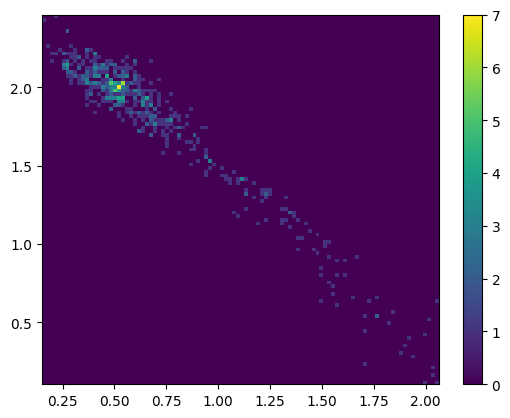

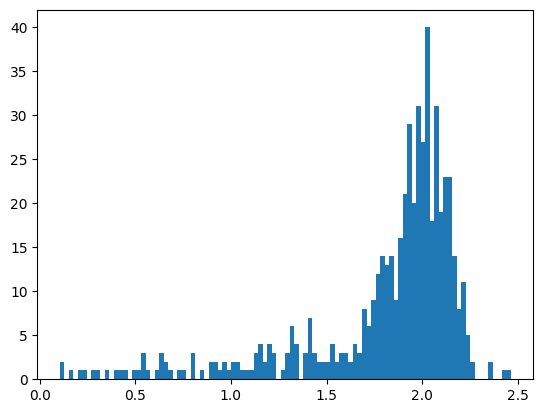

In [4]:
plt.hist2d(split_x1, split_x2, bins=100)
plt.colorbar()
plt.show()

plt.hist(split_x2, bins=100)
plt.show() 

Batch 0, current empirical splits: 0
Batch 1, current empirical splits: 17
Batch 2, current empirical splits: 48
Batch 3, current empirical splits: 73
Batch 4, current empirical splits: 103
Batch 5, current empirical splits: 119
Batch 6, current empirical splits: 130
Batch 7, current empirical splits: 153
Batch 8, current empirical splits: 187
Batch 9, current empirical splits: 204
Batch 10, current empirical splits: 234
Batch 11, current empirical splits: 279
Batch 12, current empirical splits: 303
Batch 13, current empirical splits: 325
Batch 14, current empirical splits: 357
Batch 15, current empirical splits: 382
Batch 16, current empirical splits: 409
Batch 17, current empirical splits: 430
Batch 18, current empirical splits: 449
Batch 19, current empirical splits: 481
Batch 20, current empirical splits: 481
Batch 21, current empirical splits: 500
Batch 22, current empirical splits: 526
Batch 23, current empirical splits: 571
Batch 24, current empirical splits: 607
Batch 25, curre

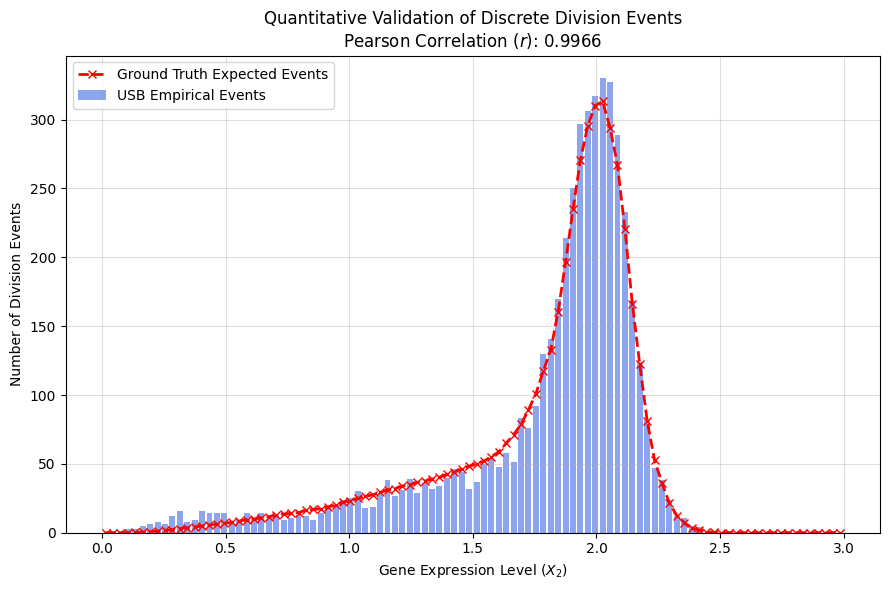

In [5]:
from utils import SDE, plot_branching_phase_portrait, plot_branching_phase_portrait2
Xs = [] 
max_sample_time = int(np.max(data['samples']))
for k in range(max_sample_time + 1): 
    Xs.append(np.array(data[data['samples'] == k])[:, 1:]) 

model = torch.load(f'{data_name}_{delta}_{nu}.pth', weights_only=False, map_location=torch.device('cpu'))
model.eval()
simulator = SDE(model, nu, mode = 3, positive=False) 

from scipy.stats import pearsonr

# 假设前面已经定义了 data, Xs, model, simulator 等
# ... (保留你原有的加载模型和设置 Xs 的代码)

split_x1 = []
split_x2 = []

# ==========================================
# 新增: 为定量统计准备分箱和 Ground Truth 参数
# ==========================================
alpha_g = 0.5  # ★ 注意: 请确保这个值与你生成 Simulation 数据时使用的 alpha_g 完全一致
bins = 100
# 根据你的 X2 数据范围调整，Simulation 数据集的 X2 通常在 0 到 3 左右
min_x2, max_x2 = 0.0, 3.0  
bin_edges = np.linspace(min_x2, max_x2, bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
expected_counts = np.zeros(bins)

T = max_sample_time
N = max_sample_time * 100
dt = T / N

for i in range(200):
    print(f"Batch {i}, current empirical splits: {len(split_x1)}")
    x_source = torch.tensor(Xs[0][(i*10)%200:((i+1)*10)%200], dtype=torch.float32, device='cpu') 
    genealogy, ms, action = simulator.trajectory(
        x=x_source, 
        m=torch.zeros([x_source.size(0),1], device='cpu'), 
        delta=delta, 
        T=T, 
        N=N
    ) 

    for k in range(len(genealogy)):
        # ==========================================
        # 1. 记录模型实际触发的分裂事件 (Empirical Events)
        # ==========================================
        # 如果轨迹起始时间 > 0，说明它是从分裂事件中“出生”的细胞
        if genealogy[k]['t'][0] > 0:
            split_x1.append(genealogy[k]['x'][0][0].item())
            split_x2.append(genealogy[k]['x'][0][1].item())

        # ==========================================
        # 2. 累加理论期望的分裂次数 (Expected Events)
        # ==========================================
        # 提取这条轨迹上所有的 X2 坐标
        if torch.is_tensor(genealogy[k]['x']):
            traj_x2 = genealogy[k]['x'][:, 1].cpu().numpy()
        else:
            traj_x2 = np.array([pt[1].item() for pt in genealogy[k]['x']])
        
        # 计算这条轨迹在每个时间步的真实分裂期望：E = g_true * dt
        g_true_vals = alpha_g * (traj_x2**2) / (1.0 + traj_x2**2)
        expected_probs = g_true_vals * dt
        
        # 找到每个点对应的分箱，并将期望值累加进去
        bin_indices = np.digitize(traj_x2, bin_edges) - 1
        valid_mask = (bin_indices >= 0) & (bin_indices < bins)
        np.add.at(expected_counts, bin_indices[valid_mask], expected_probs[valid_mask])

print(f"Total empirical division events simulated: {len(split_x1)}")

# ==========================================
# 3. 统计结果、计算相关性并绘图
# ==========================================
# 统计 USB 实际触发的分裂次数在各个分箱的分布
empirical_counts, _ = np.histogram(split_x2, bins=bin_edges)

# 【重要细节】如果你的模拟器逻辑是：1个母细胞分裂，生成 2 条全新的子细胞轨迹
# 那么上面判断 `t[0] > 0` 就会把 1 次物理分裂事件记成 2 次“出生”。
# 这种情况下，你需要把统计出来的次数除以 2，还原成真实的物理事件数。
# empirical_counts = empirical_counts / 2.0  # <--- 根据你的代码逻辑决定是否取消注释

# 过滤掉理论期望为 0 的空箱子，防止计算 Pearson 时除以零
valid_bins = expected_counts > 0
if np.sum(valid_bins) > 1:
    corr, p_val = pearsonr(empirical_counts[valid_bins], expected_counts[valid_bins])
else:
    corr = 0.0

# 绘制验证图表
plt.figure(figsize=(9, 6))
plt.plot(bin_centers, expected_counts, 'r--', label='Ground Truth Expected Events', marker='x', linewidth=2)
plt.bar(bin_centers, empirical_counts, width=(max_x2 - min_x2) / bins * 0.8, alpha=0.6, label='USB Empirical Events', color='royalblue')

plt.title(f'Quantitative Validation of Discrete Division Events\nPearson Correlation ($r$): {corr:.4f}')
plt.xlabel('Gene Expression Level ($X_2$)')
plt.ylabel('Number of Division Events')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{data_name}_division_event_validation.png', dpi=300)
plt.show()

In [6]:
np.sum(np.abs(expected_counts-empirical_counts))/ np.sum(expected_counts)

np.float64(0.10819302636283662)

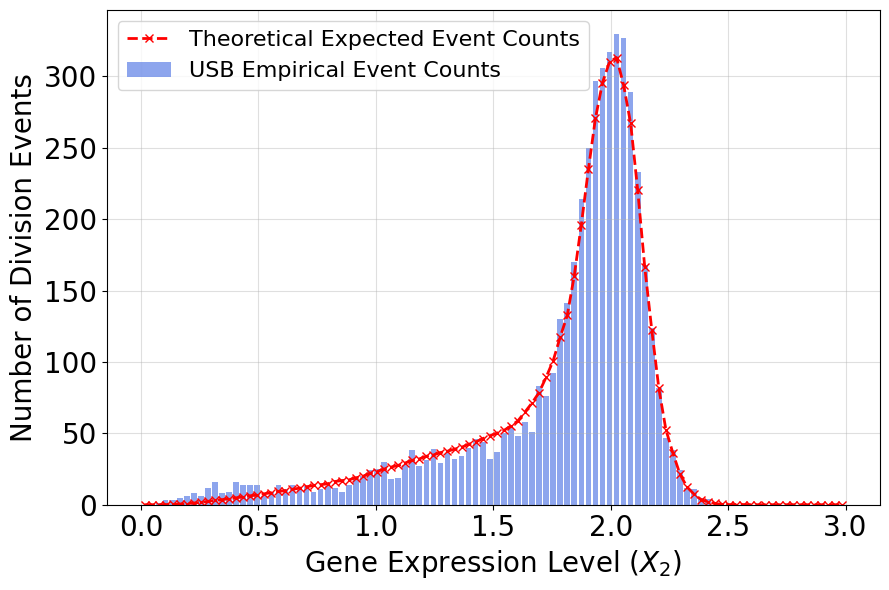

In [15]:
# 绘制验证图表
plt.figure(figsize=(9, 6))
plt.plot(bin_centers, expected_counts, 'r--', label='Theoretical Expected Event Counts', marker='x', linewidth=2)
plt.bar(bin_centers, empirical_counts, width=(max_x2 - min_x2) / bins * 0.8, alpha=0.6, label='USB Empirical Event Counts', color='royalblue')

# plt.title(f'Quantitative Validation of Discrete Division Events\nPearson Correlation ($r$): {corr:.4f}')
plt.xlabel('Gene Expression Level ($X_2$)', fontsize=20)
plt.ylabel('Number of Division Events', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{data_name}_division_event_validation.png', dpi=300)
plt.show()